## Examine the model before training


In [11]:
from PIL import Image
import torch

In [12]:
from fairface_vit import FairFaceViT

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

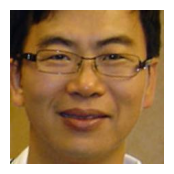

In [13]:
image = Image.open("dataset/temp/image.jpg")

plt.figure(figsize=(2,2))
plt.imshow(image)
plt.axis('off')

### CLIP

In [14]:
from model.clip import model as clip_model, processor as clip_processor

In [ ]:
fairface_clip_model = FairFaceViT(clip_model)

In [16]:
print(clip_model.config)

CLIPVisionConfig {
  "add_cross_attention": false,
  "attention_dropout": 0.0,
  "bos_token_id": null,
  "decoder_start_token_id": null,
  "dropout": 0.0,
  "dtype": "float32",
  "eos_token_id": null,
  "finetuning_task": null,
  "hidden_act": "quick_gelu",
  "hidden_size": 768,
  "image_size": 224,
  "initializer_factor": 1.0,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-05,
  "model_type": "clip_vision_model",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "pad_token_id": null,
  "patch_size": 16,
  "prefix": null,
  "projection_dim": 512,
  "pruned_heads": {},
  "sep_token_id": null,
  "task_specific_params": null,
  "tie_encoder_decoder": false,
  "tie_word_embeddings": true,
  "tokenizer_class": null,
  "torchscript": false,
  "transformers_version": "5.12.1",
  "use_bfloat16": false
}



In [17]:
# print(type(clip_model.vision_model))

In [18]:
for param in fairface_clip_model.backbone.parameters():
    print(param.requires_grad)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
Fals

In [19]:
i = 0
for name, param in fairface_clip_model.named_parameters():
    # print(i)
    if param.requires_grad:
        print(name)
    i += 1

# len(fairface_model.named_parameters())    

gender.weight
gender.bias
age.0.weight
age.0.bias
age.3.weight
age.3.bias
race.weight
race.bias


In [20]:
total = sum(p.numel() for p in fairface_clip_model.parameters())
trainable = sum(p.numel() for p in fairface_clip_model.parameters() if p.requires_grad)

print("Total:", total)
print("Trainable:", trainable)
print("Percentage:", trainable / total * 100)

Total: 86104337
Trainable: 304913
Percentage: 0.3541203737507438


In [21]:
inputs = clip_processor(
    images=image,
    return_tensors='pt'
)

In [22]:
pixel_values = inputs['pixel_values']
# print(pixel_values)
print(inputs)


{'pixel_values': tensor([[[[-1.5295, -1.5149, -1.5149,  ...,  0.2223,  0.3245,  0.3537],
          [-1.5441, -1.5295, -1.5149,  ...,  0.2369,  0.3391,  0.3683],
          [-1.5733, -1.5587, -1.5441,  ...,  0.2661,  0.3537,  0.3975],
          ...,
          [-1.0915, -0.7412, -0.2886,  ...,  0.3975,  0.3537,  0.3245],
          [-1.0623, -0.1718,  0.5873,  ...,  0.3829,  0.3391,  0.3099],
          [-0.4200,  0.4851,  0.9522,  ...,  0.3683,  0.3245,  0.2953]],

         [[-1.4820, -1.4669, -1.4669,  ..., -0.0712, -0.0112,  0.0188],
          [-1.4970, -1.4820, -1.4669,  ..., -0.0562,  0.0038,  0.0338],
          [-1.5270, -1.5120, -1.4970,  ..., -0.0262,  0.0188,  0.0638],
          ...,
          [-1.0317, -0.7016, -0.2213,  ...,  0.0638,  0.0188,  0.0038],
          [-0.9417, -0.0262,  0.7242,  ...,  0.0638,  0.0188, -0.0112],
          [-0.2363,  0.6942,  1.0994,  ...,  0.0488,  0.0038, -0.0262]],

         [[-1.1958, -1.1816, -1.1816,  ..., -0.7266, -0.6555, -0.6270],
          [-1

In [23]:
help(fairface_clip_model.forward)

Help on method forward in module fairface_vit:

forward(x) method of fairface_vit.FairFaceViT instance
    Define the computation performed at every call.

    Should be overridden by all subclasses.

    .. note::
        Although the recipe for forward pass needs to be defined within
        this function, one should call the :class:`Module` instance afterwards
        instead of this since the former takes care of running the
        registered hooks while the latter silently ignores them.



In [24]:
gender_logits, age_logits, race_logits = fairface_clip_model(pixel_values)

In [25]:
print(
    f"gender: {gender_logits.tolist()[0]}\n",
    f"age: {age_logits.tolist()[0]}\n",
    f"race: {race_logits.tolist()[0]}\n"
)

gender: [0.17074428498744965]
 age: [-0.2979312539100647, 0.005929987877607346, -0.08170577883720398, -0.018295440822839737, -0.36485421657562256, 0.06784671545028687, 0.2127518206834793, -0.17980337142944336, 0.31226179003715515]
 race: [0.8462369441986084, 0.4377862215042114, 0.05314724147319794, 0.03838403522968292, -0.5526629090309143, -0.7957065105438232, 0.62018221616745]



In [26]:
gender_prob = torch.sigmoid(gender_logits)
age_prob = torch.softmax(age_logits, dim=1)
race_prob = torch.softmax(race_logits, dim=1)

In [27]:
print(
    f"gender: {gender_prob}\n",
    f"age: {age_prob}\n",
    f"race: {race_prob}\n"
)

gender: tensor([[0.5426]], grad_fn=<SigmoidBackward0>)
 age: tensor([[0.0838, 0.1136, 0.1041, 0.1109, 0.0784, 0.1209, 0.1397, 0.0943, 0.1543]],
       grad_fn=<SoftmaxBackward0>)
 race: tensor([[0.2631, 0.1749, 0.1190, 0.1173, 0.0649, 0.0509, 0.2099]],
       grad_fn=<SoftmaxBackward0>)



### SigLip

In [28]:
from model.siglip import model as siglip_model, processor as siglip_processor

In [29]:
fairface_siglip_model = FairFaceViT(siglip_model)

backbone:  SiglipVisionModel(
  (embeddings): SiglipVisionEmbeddings(
    (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
    (position_embedding): Embedding(196, 768)
  )
  (encoder): SiglipEncoder(
    (layers): ModuleList(
      (0-11): 12 x SiglipEncoderLayer(
        (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (self_attn): SiglipAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layer_norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (mlp): SiglipMLP(
          (activation_fn): GELUTanh()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, 

In [30]:
print(siglip_model.config)

SiglipVisionConfig {
  "attention_dropout": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu_pytorch_tanh",
  "hidden_size": 768,
  "image_size": 224,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-06,
  "model_type": "siglip_vision_model",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "transformers_version": "5.12.1"
}



In [31]:
for param in fairface_siglip_model.backbone.parameters():
    print(param.requires_grad)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
Fals

In [32]:
for name, param in fairface_siglip_model.named_parameters():
    if param.requires_grad:
        print(name)

gender.weight
gender.bias
age.0.weight
age.0.bias
age.3.weight
age.3.bias
race.weight
race.bias


In [33]:
total = sum(p.numel() for p in fairface_siglip_model.parameters())
trainable = sum(p.numel() for p in fairface_siglip_model.parameters() if p.requires_grad)

print("Total:", total)
print("Trainable:", trainable)
print("Percentage:", trainable / total * 100)

Total: 93189137
Trainable: 304913
Percentage: 0.327198008068258


In [34]:
inputs = siglip_processor(
    images=image,
    return_tensors='pt'
)

In [35]:
pixel_values = inputs['pixel_values']
# print(pixel_values)
print(inputs)

{'pixel_values': tensor([[[[-0.8588, -0.8510, -0.8510,  ...,  0.0824,  0.1373,  0.1529],
          [-0.8667, -0.8588, -0.8510,  ...,  0.0902,  0.1451,  0.1608],
          [-0.8824, -0.8745, -0.8667,  ...,  0.1059,  0.1529,  0.1765],
          ...,
          [-0.6235, -0.4353, -0.1922,  ...,  0.1765,  0.1529,  0.1373],
          [-0.6078, -0.1294,  0.2784,  ...,  0.1686,  0.1451,  0.1294],
          [-0.2627,  0.2235,  0.4745,  ...,  0.1608,  0.1373,  0.1216]],

         [[-0.8588, -0.8510, -0.8510,  ..., -0.1216, -0.0902, -0.0745],
          [-0.8667, -0.8588, -0.8510,  ..., -0.1137, -0.0824, -0.0667],
          [-0.8824, -0.8745, -0.8667,  ..., -0.0980, -0.0745, -0.0510],
          ...,
          [-0.6235, -0.4510, -0.2000,  ..., -0.0510, -0.0745, -0.0824],
          [-0.5765, -0.0980,  0.2941,  ..., -0.0510, -0.0745, -0.0902],
          [-0.2078,  0.2784,  0.4902,  ..., -0.0588, -0.0824, -0.0980]],

         [[-0.8431, -0.8353, -0.8353,  ..., -0.5843, -0.5451, -0.5294],
          [-0

In [36]:
help(fairface_siglip_model.forward)

Help on method forward in module fairface_vit:

forward(x) method of fairface_vit.FairFaceViT instance
    Define the computation performed at every call.

    Should be overridden by all subclasses.

    .. note::
        Although the recipe for forward pass needs to be defined within
        this function, one should call the :class:`Module` instance afterwards
        instead of this since the former takes care of running the
        registered hooks while the latter silently ignores them.



In [37]:
gender_logits, age_logits, race_logits = fairface_siglip_model(pixel_values)

In [38]:
print(
    f"gender: {gender_logits.tolist()[0]}\n",
    f"age: {age_logits.tolist()[0]}\n",
    f"race: {race_logits.tolist()[0]}\n"
)

gender: [-0.8037462830543518]
 age: [-0.04985971376299858, -0.14147914946079254, -0.012774934992194176, 0.05354347825050354, -0.07496944069862366, 0.12698246538639069, -0.07516477257013321, -0.007074818015098572, -0.049819380044937134]
 race: [-0.10905645787715912, 0.03673489764332771, -0.22317232191562653, 0.062472276389598846, -0.2879371643066406, 0.17116737365722656, 0.24044546484947205]



In [39]:
gender_prob = torch.sigmoid(gender_logits)
age_prob = torch.softmax(age_logits, dim=1)
race_prob = torch.softmax(race_logits, dim=1)

In [40]:
print(
    f"gender: {gender_prob}\n",
    f"age: {age_prob}\n",
    f"race: {race_prob}\n"
)

gender: tensor([[0.3092]], grad_fn=<SigmoidBackward0>)
 age: tensor([[0.1081, 0.0987, 0.1122, 0.1199, 0.1055, 0.1291, 0.1054, 0.1129, 0.1082]],
       grad_fn=<SoftmaxBackward0>)
 race: tensor([[0.1280, 0.1481, 0.1142, 0.1519, 0.1070, 0.1694, 0.1815]],
       grad_fn=<SoftmaxBackward0>)



### DinoV2


In [41]:
from model.dinov2 import model as dinov2_model, processor as dinov2_processor

In [42]:
fairface_dinov2_model = FairFaceViT(dinov2_model)

backbone:  Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerN

KeyboardInterrupt: 

In [ ]:
print(dinov2_model.config)

Dinov2Config {
  "apply_layernorm": true,
  "architectures": [
    "Dinov2Model"
  ],
  "attention_probs_dropout_prob": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 518,
  "initializer_range": 0.02,
  "layer_norm_eps": 1e-06,
  "layerscale_value": 1.0,
  "mlp_ratio": 4,
  "model_type": "dinov2",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "out_features": [
    "stage12"
  ],
  "out_indices": [
    12
  ],
  "patch_size": 14,
  "qkv_bias": true,
  "reshape_hidden_states": true,
  "stage_names": [
    "stem",
    "stage1",
    "stage2",
    "stage3",
    "stage4",
    "stage5",
    "stage6",
    "stage7",
    "stage8",
    "stage9",
    "stage10",
    "stage11",
    "stage12"
  ],
  "transformers_version": "5.12.1",
  "use_mask_token": true,
  "use_swiglu_ffn": false
}



In [ ]:
for param in fairface_dinov2_model.backbone.parameters():
    print(param.requires_grad)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
Fals

In [ ]:
for name, param in fairface_dinov2_model.named_parameters():
    if param.requires_grad:
        print(name)

gender.weight
gender.bias
age.0.weight
age.0.bias
age.3.weight
age.3.bias
race.weight
race.bias


In [ ]:
total = sum(p.numel() for p in fairface_dinov2_model.parameters())
trainable = sum(p.numel() for p in fairface_dinov2_model.parameters() if p.requires_grad)

print("Total:", total)
print("Trainable:", trainable)
print("Percentage:", trainable / total * 100)

Total: 86885393
Trainable: 304913
Percentage: 0.35093700963060614


In [ ]:
inputs = dinov2_processor(
    images=image,
    return_tensors='pt'
)

In [ ]:
print(dinov2_processor)

BitImageProcessor {
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "BitImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 256
  }
}



In [ ]:
pixel_values_ = inputs['pixel_values']
# print(pixel_values)
print(inputs)

{'pixel_values': tensor([[[[-1.9467, -1.9638, -1.9809,  ..., -1.6898, -1.6213, -1.6727],
          [-1.9467, -1.9638, -1.9809,  ..., -1.7069, -1.6042, -1.6898],
          [-1.9638, -1.9809, -1.9638,  ..., -1.7754, -1.7754, -1.7583],
          ...,
          [ 0.4851,  0.5364,  0.9646,  ...,  0.6049,  0.6221,  0.6049],
          [ 0.6392,  0.8618,  1.3927,  ...,  0.5878,  0.5878,  0.5878],
          [ 0.8961,  1.1700,  1.5468,  ...,  0.5707,  0.5707,  0.5707]],

         [[-1.8782, -1.8782, -1.8606,  ..., -1.6331, -1.5280, -1.5805],
          [-1.8782, -1.8606, -1.8782,  ..., -1.6155, -1.5280, -1.5980],
          [-1.8782, -1.8957, -1.8957,  ..., -1.7031, -1.7031, -1.6681],
          ...,
          [-0.0049,  0.0826,  0.5553,  ...,  0.2402,  0.2577,  0.2402],
          [ 0.2227,  0.4853,  1.1331,  ...,  0.2402,  0.2227,  0.2052],
          [ 0.5028,  0.8880,  1.3431,  ...,  0.2227,  0.2052,  0.1877]],

         [[-1.5081, -1.5081, -1.5256,  ..., -1.5256, -1.4733, -1.5256],
          [-1

In [ ]:
help(fairface_dinov2_model.forward)

Help on method forward in module fairface_vit:

forward(x) method of fairface_vit.FairFaceViT instance
    Define the computation performed at every call.

    Should be overridden by all subclasses.

    .. note::
        Although the recipe for forward pass needs to be defined within
        this function, one should call the :class:`Module` instance afterwards
        instead of this since the former takes care of running the
        registered hooks while the latter silently ignores them.



In [ ]:
gender_logits_dinov2, age_logits_dinov2, race_logits_dinov2 = fairface_dinov2_model(pixel_values)

In [ ]:
print(
    f"gender: {gender_logits.tolist()[0]}\n",
    f"age: {age_logits.tolist()[0]}\n",
    f"race: {race_logits.tolist()[0]}\n"
)

gender: [0.08902216702699661]
 age: [0.017394598573446274, -0.038951508700847626, 0.12768083810806274, 0.028938475996255875, -0.0371985100209713, -0.11812351644039154, -0.05966787785291672, -0.027564948424696922, -0.10682888329029083]
 race: [0.2998754680156708, -1.1792526245117188, -0.18584002554416656, -0.37985193729400635, 0.06394936889410019, 0.16221259534358978, -0.08625507354736328]



In [ ]:
gender_prob = torch.sigmoid(gender_logits)
age_prob = torch.softmax(age_logits, dim=1)
race_prob = torch.softmax(race_logits, dim=1)

In [ ]:
print(
    f"gender: {gender_prob}\n",
    f"age: {age_prob}\n",
    f"race: {race_prob}\n"
)

gender: tensor([[0.5222]], grad_fn=<SigmoidBackward0>)
 age: tensor([[0.1155, 0.1092, 0.1290, 0.1168, 0.1094, 0.1009, 0.1069, 0.1104, 0.1020]],
       grad_fn=<SoftmaxBackward0>)
 race: tensor([[0.2132, 0.0486, 0.1312, 0.1080, 0.1684, 0.1858, 0.1449]],
       grad_fn=<SoftmaxBackward0>)



## Test Transform on a image

In [ ]:
from dataset.transforms import get_train_transform, get_age_transform
from dataset.dataloader import get_dataset, get_dataloaders

import matplotlib.pyplot as plt

In [ ]:
train_set, val_set = get_dataset()
train_dataloader, val_dataloader = get_dataloaders(train_set, val_set)

In [ ]:
from model.clip import processor as clip_processor
from model.siglip import processor as siglip_processor

from model.dinov2 import processor as dinov2_processor

In [ ]:
img,label = train_set[5]
# plt.imshow(img)

transform = get_train_transform(clip_processor.image_processor)

age_transform_clip = get_age_transform(clip_processor.image_processor)
age_transform_siglip = get_age_transform(siglip_processor)
age_transform_dinov2 = get_age_transform(dinov2_processor)



plt.figure(figsize=(10,6))

plt.subplot(2,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

transformed_img = age_transform_clip(img)
plt.subplot(2,2,2)
plt.imshow(transformed_img.permute(1, 2, 0))
plt.title("clip normalized Augmented")
plt.axis("off")

transformed_img = age_transform_siglip(img)
plt.subplot(2,2,3)
plt.imshow(transformed_img.permute(1, 2, 0))
plt.title("siglip normalized Augmented")
plt.axis("off")

transformed_img = age_transform_dinov2(img)
plt.subplot(2,4)
plt.imshow(transformed_img.permute(1, 2, 0))
plt.title("dinov2 normalized Augmented")
plt.axis("off")


plt.show()

## Check training steps

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

In [6]:
from dataset.dataloader import get_dataset, get_dataloaders
from dataset.transforms import get_train_transform, get_age_transform, get_val_transform

In [7]:
from model.clip   import model as clip_model, processor as clip_processor
from model.dinov2 import model as dinov2_model, processor as dinov2_processor
from model.siglip import model as siglip_model, processor as siglip_processor

from fairface_vit import FairFaceViT

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [9]:
fairface_clip_model = FairFaceViT(clip_model).to(device)

backbone:  CLIPVisionModel(
  (embeddings): CLIPVisionEmbeddings(
    (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)
    (position_embedding): Embedding(197, 768)
  )
  (pre_layrnorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (encoder): CLIPEncoder(
    (layers): ModuleList(
      (0-11): 12 x CLIPEncoderLayer(
        (self_attn): CLIPAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): CLIPMLP(
          (activation_fn): QuickGELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_featu

In [10]:
train_set, val_set = get_dataset(
    get_train_transform(clip_processor.image_processor), 
    get_age_transform(clip_processor.image_processor), 
    get_val_transform(clip_processor.image_processor)
)
train_dataloader, val_dataloader = get_dataloaders(train_set, val_set)

In [11]:
print("number of batched: ",len(train_dataloader))
X, Y = next(iter(train_dataloader))
# images and lables blongs to 32 samples (1 batch) 

number of batched:  2711


In [12]:
X, Y = next(iter(train_dataloader))

print("X.shape:" ,X.shape)
print("batch size:" ,X.size(0))

for k, v in Y.items():
    print(k, v.shape, v.dtype)

X.shape: torch.Size([32, 3, 224, 224])
batch size: 32
gender torch.Size([32]) torch.int64
age torch.Size([32]) torch.int64
race torch.Size([32]) torch.int64


In [13]:
X = X.to(device)
Y = {k: v.to(device) for k, v in Y.items()}

pred = fairface_clip_model(X)
# print('pred:', pred)
print(type(pred))
print(len(pred))
    
for k, v in pred.items():
    print(k, v.shape)

<class 'dict'>
3
gender torch.Size([32, 1])
age torch.Size([32, 9])
race torch.Size([32, 7])


### Check Loss fucntions

In [14]:
from training.losses import get_age_weights, get_loss_function, compute_losses

In [15]:
age_labels = np.array(train_set.dataset['age'])
age_weights = get_age_weights(age_labels, 9, device)

In [16]:
loss_funcs = get_loss_function(age_weights)

In [17]:
print(loss_funcs)

{'gender': BCEWithLogitsLoss(), 'age': CrossEntropyLoss(), 'race': CrossEntropyLoss()}


In [18]:
total_loss, losses = compute_losses(pred, Y, loss_funcs)



In [19]:
print(type(total_loss), type(losses))

print(total_loss)

for key,value in losses.items():
    print(key,value)

<class 'torch.Tensor'> <class 'dict'>
tensor(5.0764, device='cuda:0', grad_fn=<AddBackward0>)
gender tensor(0.8177, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
age tensor(2.2292, device='cuda:0', grad_fn=<NllLossBackward0>)
race tensor(2.0296, device='cuda:0', grad_fn=<NllLossBackward0>)


### Check Backward

In [20]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, fairface_clip_model.parameters()),
    lr=1e-4,
    weight_decay=0.01
)

# print(optimizer)

In [21]:
optimizer.zero_grad()

total_loss.backward()

optimizer.step()

In [22]:
for name, param in fairface_clip_model.named_parameters():
    if param.requires_grad:
        print(type(param))
        print(name, param.grad.abs().mean())
        break

# fairface_clip_model.named_parameters()    

<class 'torch.nn.parameter.Parameter'>
gender.weight tensor(0.1389, device='cuda:0')


### Check Train loop

In [23]:
from training.train import train_loop

In [24]:
# train_loop(train_dataloader,fairface_clip_model,loss_funcs,None,optimizer,device)

In [25]:
from training.train import test_loop

In [26]:
# test_loop(train_dataloader,fairface_clip_model, loss_funcs, None,device)

### Check traning with small dataset

In [1]:
from model.clip import model as clip_model, processor as clip_processor

/home/ashkanrn/01-Project/University/Deep-Learning/DL-project/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16314.19it/s]
[transformers] CLIPVisionModel LOAD REPORT from: ../models/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UN

In [2]:
from dataset.dataloader import get_dataset, get_dataloaders
from dataset.transforms import get_train_transform, get_age_transform, get_val_transform

train_set, val_set = get_dataset(
    get_train_transform(clip_processor.image_processor), 
    get_age_transform(clip_processor.image_processor), 
    get_val_transform(clip_processor.image_processor)
)
train_dataloader, val_dataloader = get_dataloaders(train_set, val_set)

In [3]:
from torch.utils.data import Subset
from torch.utils.data import DataLoader
from training.train import test_loop

indices = list(range(30))      # first 30 samples
tiny_dataset = Subset(train_set, indices)

In [4]:
tiny_loader = DataLoader(
    tiny_dataset,
    batch_size=8,
    shuffle=True,
)

In [5]:
import numpy as np
from training.train import train_loop,test_loop



In [6]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

In [7]:
from fairface_vit import FairFaceViT
fairface_clip_model = FairFaceViT(clip_model)
fairface_clip_model.to(device)

backbone:  CLIPVisionModel(
  (embeddings): CLIPVisionEmbeddings(
    (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)
    (position_embedding): Embedding(197, 768)
  )
  (pre_layrnorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (encoder): CLIPEncoder(
    (layers): ModuleList(
      (0-11): 12 x CLIPEncoderLayer(
        (self_attn): CLIPAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): CLIPMLP(
          (activation_fn): QuickGELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_featu

FairFaceViT(
  (backbone): CLIPVisionModel(
    (embeddings): CLIPVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)
      (position_embedding): Embedding(197, 768)
    )
    (pre_layrnorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)

In [8]:
from training.losses import get_age_weights, get_loss_function, compute_losses
age_labels = np.array(train_set.dataset['age'])
age_weights = get_age_weights(age_labels, 9, device)
loss_funcs = get_loss_function(age_weights)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, fairface_clip_model.parameters()),
    lr=3e-4,
    weight_decay=0.01
)

In [10]:
print(optimizer.param_groups[0]["lr"])

0.0003


In [9]:
epochs = 50
avg_loss = 0.0
avg_task_losses = {}
overall = {}
subgroups_accuracy = {}
for t in range(epochs):
    print(f"Epoch {t+1}\n--------------------------------------------")
    train_loop(tiny_loader,fairface_clip_model,loss_funcs, None, optimizer, device)
    avg_loss, avg_task_losses, overall, subgroups_accuracy = test_loop(tiny_loader, fairface_clip_model, loss_funcs, None, device)
    print("\n")
print("Done!")



Epoch 1
--------------------------------------------

----------TRAIN----------
 loss: 4.865450  [    8/   30]

 avg loss:        4.8784
 avg age loss:    2.19
 avg gender loss: 0.77
 avg race loss:   1.92

 gender: acc=0.433  f1=0.190
 age:    acc=0.200  f1=0.101  mae=2.000
 race:   acc=0.167  f1=0.088

----------TEST----------
 avg loss: 4.2681
 gender: acc=0.500  f1=0.348
 age:    acc=0.233  f1=0.254   mae=1.933
 race:   acc=0.533  f1=0.311


Epoch 2
--------------------------------------------

----------TRAIN----------
 loss: 4.199025  [    8/   30]

 avg loss:        4.1830
 avg age loss:    1.76
 avg gender loss: 0.68
 avg race loss:   1.74

 gender: acc=0.567  f1=0.480
 age:    acc=0.267  f1=0.369  mae=1.900
 race:   acc=0.467  f1=0.310

----------TEST----------
 avg loss: 3.8471
 gender: acc=0.700  f1=0.710
 age:    acc=0.233  f1=0.124   mae=1.833
 race:   acc=0.500  f1=0.318


Epoch 3
--------------------------------------------

----------TRAIN----------
 loss: 3.665555  [  

KeyboardInterrupt: 

In [ ]:
for key,value in overall.items():
    print(key,value)

gender {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}
age {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'mse': 0.0, 'rmse': 0.0, 'mae': 0.0}
race {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}
